# Haplosaurus

In [6]:
%load_ext autoreload
%autoreload 2

import os
os.chdir('/grid/koo/home/schilder/projects/GenomeEncoder/')
import pandas as pd
import sys
sys.path.append("code")
import src.haplosaurus as hs
import src.ESM as ESM
import src.onekg as onekg
from tqdm.auto import tqdm

import os
# os.chdir("/grid/koo/home/schilder/projects/GenomeEncoder/data")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
client = hs.get_ensembl_client()

In [ ]:
# %%R

# db = EnsDb.Hsapiens.v86::EnsDb.Hsapiens.v86
# # get the transcript to protein ID mappings
# txs <- GenomicFeatures::transcripts(db, columns = c("tx_id","protein_id"))
# txs <- txs[!is.na(txs$protein_id)]
# data.table::fwrite(data.frame(txs), "data/bioc/bioc_tx_to_prot.csv.gz")

## Get transcripts

In [3]:
# hs_db = hs.get_figshare("haplotype_analysis_database.zip")
# #  List all files in the directory
# hs_db_files = [f"{hs_db}/{x}" for x in os.listdir(hs_db)]
# hs_db_sql = [x for x in hs_db_files if x.endswith(".sql.gz")][0]
# hs_db_files
# import mysql.connector
# conn = mysql.connector.connect(
# host="localhost",
# user="root",
# password="root",
# database="haplotype_analysis_database"
# )
# cursor = conn.cursor()

In [3]:
# Haplosaurus protein IDs
tx_df = pd.read_excel("data/haplosaurus/41467_2018_6542_MOESM4_ESM.xlsx")
print(tx_df.shape)
# Bioconductor transcript to protein ID
tx_to_prot = pd.read_csv("data/bioc/bioc_tx_to_prot.csv.gz")
print(tx_to_prot.shape)
tx_df = tx_df.merge(tx_to_prot.drop_duplicates(subset=['tx_id', 'protein_id']),
                    left_on="Ensembl Protein ID", 
                    right_on="protein_id", 
                    how="inner") 
print(tx_df.shape)
tx_df.head()

(20166, 6)
(109705, 9)
(18494, 15)


/grid/it/data/elzar/easybuild/software/Python/3.9.5-GCCcore-10.3.0/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3098: DtypeWarning: Columns (0) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,Ensembl Gene ID,Ensembl Protein ID,Gene Name,Number of Haplotypes,Number of Haplotypes FoO>=1%,Frequency Rank of Reference Protein Haplotype,seqnames,start,end,width,strand,protein_id,uniprot_id,tx_biotype,tx_id
0,ENSG00000121410,ENSP00000263100,A1BG,44,3.0,2.0,19,58346850,58353499,6650,-,ENSP00000263100,P04217,protein_coding,ENST00000263100
1,ENSG00000148584,ENSP00000363107,A1CF,25,2.0,1.0,10,50806562,50885675,79114,-,ENSP00000363107,Q9NQ94,protein_coding,ENST00000373995
2,ENSG00000175899,ENSP00000323929,A2M,69,5.0,10.0,12,9067712,9116157,48446,-,ENSP00000323929,P01023,protein_coding,ENST00000318602
3,ENSG00000166535,ENSP00000299698,A2ML1,171,9.0,10.0,12,8822472,8876785,54314,+,ENSP00000299698,A8K2U0,protein_coding,ENST00000299698
4,ENSG00000184389,ENSP00000475261,A3GALT2,34,1.0,1.0,1,33306766,33321098,14333,-,ENSP00000475261,U3KPV4,protein_coding,ENST00000442999


<AxesSubplot:>

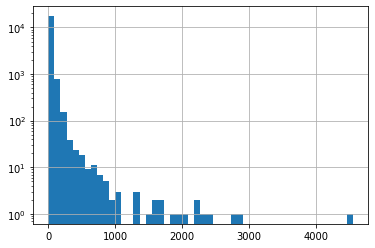

In [4]:
tx_df['Number of Haplotypes'].hist(bins=50, log=True)

In [13]:
# Remove MUC genes with lots of haplotypes as these may be artifacts
tx_df = tx_df[~(tx_df['Gene Name'].str.startswith('MUC') & (tx_df['Number of Haplotypes'] > 1000))]
tx_ids = list(set(tx_df['tx_id'].tolist()))
# tx_ids = tx_ids[:5]

print(len(tx_ids),"transcripts")

18490 transcripts


In [19]:
hap = {}
for tx_id in tqdm(tx_ids):
    hap[tx_id] = client.transcript_haplotypes_get(id=tx_id,
                                                species="homo_sapiens",
                                                params={'samples':1,
                                                        'sequence':1,
                                                        'aligned_sequences':1})
    

hap[tx_id].keys()

  0%|          | 0/3 [00:00<?, ?it/s]

dict_keys(['transcript_id', 'cds_haplotypes', 'protein_haplotypes', 'total_haplotype_count', 'total_population_counts'])

In [9]:
population_frequencies = hs.get_proteoform_freq(hap[tx_id])
population_frequencies

NameError: name 'hap' is not defined

In [23]:
# Gather pathogenic/benign variants
variants_pathogenic = {}
variants_benign = {}
variants_1kg = {}
valid_tx_ids = []
client = hs.get_ensembl_client(client=client)
so_term = 'SO:0001583'
for tx_id in tqdm(tx_ids[:100]):
    ## Get pathogenic variants
    varp = hs.get_variants(
        tx_id=tx_id,
        client=client,
        params_query={'feature':'variation',
                      'so_term': so_term,
                      'variant_set': 'clin_assoc'
                      },
        params_filter={'clinical_significance':['pathogenic']}
        )
    if len(varp)==0: 
        continue
    else:
        variants_pathogenic[tx_id] = varp
    ## Get benign variants
    varb = hs.get_variants(
        tx_id=tx_id,
        params_query={'feature':'variation',
                      'so_term': so_term,
                      'variant_set': 'ClinVar'
                      },
        params_filter={'clinical_significance':['benign']}
        )
    if len(varb)==0:
        continue
    else:
        variants_benign[tx_id] = varb
    ## Get 1KG variants
    var1kg = hs.get_variants(
        tx_id=tx_id,
        client=client,
        params_query={'feature':'variation',
                      'so_term': so_term,
                      'variant_set': '1kg_3' # '1kg_3_com'
                      }
        )
    if len(var1kg)>0:
        variants_1kg[tx_id] = var1kg
        ids_1kg = [x['id'] for x in var1kg]
        # Remove pathogenic variants present in 1KG
        varp = hs.filter_variants(varp, 
                                    params={'id':ids_1kg},
                                    reverse=True,
                                    verbose=False,
                                    leave=False
                                    )
        if len(varp)==0:
            continue
        # Remove benign variants present in 1KG
        varb = hs.filter_variants(varb, 
                                    params={'id':ids_1kg},
                                    reverse=True,
                                    verbose=False,
                                    leave=False
                                    )
        if len(varb)==0:
            continue
    # Append if it made it through all the filters
    valid_tx_ids.append(tx_id)

  0%|          | 0/100 [00:00<?, ?it/s]

Filtering variants:   0%|          | 0/4 [00:00<?, ?it/s]

Filtering variants:   0%|          | 0/16 [00:00<?, ?it/s]

Filtering variants:   0%|          | 0/18 [00:00<?, ?it/s]

Filtering variants:   0%|          | 0/98 [00:00<?, ?it/s]

...

Filtering variants:   0%|          | 0/10 [00:00<?, ?it/s]

Filtering variants:   0%|          | 0/82 [00:00<?, ?it/s]

Filtering variants:   0%|          | 0/12 [00:00<?, ?it/s]

Filtering variants:   0%|          | 0/1 [00:00<?, ?it/s]

Filtering variants:   0%|          | 0/19 [00:00<?, ?it/s]

In [25]:
len(valid_tx_ids)

17

In [107]:
batches = {}
# Add all haplotypes
# Reference sequence is already included as {tx_id}:REF
batches[tx_id] = [(x['name'], x['seq'].strip("*")) for x in hap_tx['protein_haplotypes']]
print(len(batches[tx_id]))
print(len(set(batches[tx_id])))
batches[tx_id][:5]


88
88


[('ENSP00000471493:11I>T,192N>K,346E>A',
  'METNSSLPTNTSGGTPAVSAGYLFLDIITYLVFAVTFVLGVLGNGLVIWVAGFRMTHTVTTISYLNLAVADFCFTSTLPFFMVRKAMGGHWPFGWFLCKFVFTIVDINLFGSVFLIALIALDRCVCVLHPVWTQNHRTVSLAKKVIIGPWVMALLLTLPVIIRVTTVPGKTGTVACTFNFSPWTNDPKERIKVAVAMLTVRGIIRFIIGFSAPMSIVAVSYGLIATKIHKQGLIKSSRPLRVLSFVAAAFFLCWSPYQVVALIATVRIRELLQGMYKEIGIAVDVTSALAFFNSCLNPMLYVFMGQDFRERLIHALPASLERALTEDSTQTSDTATNSTLPSAEVALQAK'),
 ('ENSP00000471493:11I>T,346E>A',
  'METNSSLPTNTSGGTPAVSAGYLFLDIITYLVFAVTFVLGVLGNGLVIWVAGFRMTHTVTTISYLNLAVADFCFTSTLPFFMVRKAMGGHWPFGWFLCKFVFTIVDINLFGSVFLIALIALDRCVCVLHPVWTQNHRTVSLAKKVIIGPWVMALLLTLPVIIRVTTVPGKTGTVACTFNFSPWTNDPKERINVAVAMLTVRGIIRFIIGFSAPMSIVAVSYGLIATKIHKQGLIKSSRPLRVLSFVAAAFFLCWSPYQVVALIATVRIRELLQGMYKEIGIAVDVTSALAFFNSCLNPMLYVFMGQDFRERLIHALPASLERALTEDSTQTSDTATNSTLPSAEVALQAK'),
 ('ENSP00000471493:11I>T,101V>L,346E>A',
  'METNSSLPTNTSGGTPAVSAGYLFLDIITYLVFAVTFVLGVLGNGLVIWVAGFRMTHTVTTISYLNLAVADFCFTSTLPFFMVRKAMGGHWPFGWFLCKFLFTIVDINLFGSVFLIALIALDRCVCVLHPVWTQNHRTVSLAKKVIIGPWVMALLLTLPVIIRVTTV

In [108]:
(esm_results, 
 save_paths, 
 failed_transcripts) = ESM.get_embeddings(
     batches, 
     error=True,
     save_dir="data/1KG/embeddings/esm2_t33_650M_UR50D",
    #  force=True
     )

Embedding transcript proteoforms:   0%|          | 0/1 [00:00<?, ?it/s]

In [109]:
seq_reps = ESM.get_representations(batches=batches, 
                                   save_paths=save_paths)

Found 1 ESM2 files


Extracting sequence representations:   0%|          | 0/1 [00:00<?, ?it/s]

In [110]:
(transcript_variances, 
 transcript_variance_means) = ESM.get_representation_variances(seq_reps)

transcript_variance_means

Computing transcript variances:   0%|          | 0/1 [00:00<?, ?it/s]

{'ENSP00000471493': tensor(8.1804e-06)}

In [111]:
X = ESM.get_representation_matrix(seq_reps, 
                                  save_path = "data/1KG/embeddings/esm2_t33_650M_UR50D/sequence_representation_matrix.pt")

Restructuring sequence representations into 2D array
torch.Size([88, 1280])


In [112]:
reducer, embedding, nan_indices = ESM.run_umap(X)

Filtering matrix
Matrix shape before filtering: torch.Size([88, 1280])
Matrix shape after filtering: torch.Size([88, 1280])
Running UMAP
UMAP( verbose=True)
Thu Jan  9 23:29:41 2025 Construct fuzzy simplicial set
Thu Jan  9 23:29:41 2025 Finding Nearest Neighbors
Thu Jan  9 23:29:41 2025 Finished Nearest Neighbor Search
Thu Jan  9 23:29:41 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Thu Jan  9 23:29:42 2025 Finished embedding


In [113]:
embedding_df = ESM.get_umap_df(seq_reps, embedding, nan_indices) 

In [114]:
import numpy as np
for k in population_frequencies[list(population_frequencies.keys())[0]].keys():
    # Create list of frequencies, using 0 as default when key not found, NA for reference
    frequencies = [np.nan if 'reference' in x else population_frequencies[x].get(k, 0) for x in embedding_df['label']]
    embedding_df[f'freq_{k.strip("_")}'] = frequencies
embedding_df.head()

,UMAP 1,UMAP 2,label,transcript_id,transcript,freq_1000GENOMES:phase_3:JPT,freq_1000GENOMES:phase_3:GIH,freq_1000GENOMES:phase_3:CLM,freq_1000GENOMES:phase_3:MSL,freq_1000GENOMES:phase_3:ESN,...,freq_1000GENOMES:phase_3:AFR,freq_all,freq_1000GENOMES:phase_3:GWD,freq_1000GENOMES:phase_3:EUR,freq_1000GENOMES:phase_3:PJL,freq_1000GENOMES:phase_3:PUR,freq_1000GENOMES:phase_3:CHS,freq_1000GENOMES:phase_3:CHB,freq_1000GENOMES:phase_3:KHV,freq_1000GENOMES:phase_3:YRI
0,2.690313,11.386104,"ENSP00000471493:11I>T,192N>K,346E>A",ENSP00000471493,ENSP00000471493,0.134615,0.242718,0.218085,0.152941,0.272727,...,0.226172,0.166500,0.185841,0.261431,0.229167,0.153846,0.114286,0.140777,0.101010,0.222222
1,3.681312,11.953553,"ENSP00000471493:11I>T,346E>A",ENSP00000471493,ENSP00000471493,0.120192,0.087379,0.085106,0.176471,0.131313,...,0.167927,0.156863,0.168142,0.067594,0.109375,0.096154,0.104762,0.116505,0.075758,0.236111
2,4.231814,12.139377,"ENSP00000471493:11I>T,101V>L,346E>A",ENSP00000471493,ENSP00000471493,0.072115,0.101942,0.212766,0.052941,0.040404,...,0.045386,0.127119,0.030973,0.128231,0.114583,0.129808,0.180952,0.097087,0.126263,0.037037
3,3.505685,13.675764,ENSP00000471493:11I>T,ENSP00000471493,ENSP00000471493,0.100962,0.097087,0.069149,0.111765,0.116162,...,0.119516,0.101030,0.110619,0.072565,0.104167,0.091346,0.133333,0.140777,0.126263,0.148148
4,2.787711,11.735064,"ENSP00000471493:11I>T,101V>L,192N>K,346E>A",ENSP00000471493,ENSP00000471493,0.096154,0.077670,0.037234,0.141176,0.126263,...,0.115734,0.073446,0.128319,0.052684,0.093750,0.120192,0.057143,0.053398,0.106061,0.087963


In [156]:
# Add a new column with the population in which the variant is most common
pops = population_frequencies[list(population_frequencies.keys())[0]].keys()
freq_cols = [f'freq_{p}' for p in pops if f'freq_{p}' in embedding_df.columns]
embedding_df['top_pop'] = 'reference'
if freq_cols:
    max_freq_idx = embedding_df[freq_cols].idxmax(axis=1)
    embedding_df.loc[~embedding_df[freq_cols].isna().all(axis=1), 'top_pop'] = max_freq_idx.str.replace('freq_', '').str.replace('1000GENOMES:phase_3:', '')
embedding_df.top_pop.value_counts()

JPT    11
GWD     7
CHB     7
LWK     6
CDX     5
YRI     5
MSL     5
PEL     5
ACB     5
ESN     4
KHV     4
ITU     4
ASW     3
STU     3
IBS     3
CEU     3
PUR     3
CLM     1
MXL     1
GBR     1
CHS     1
GIH     1
Name: top_pop, dtype: int64

In [159]:
pops = onekg.get_sample_metadata()
pop_map = dict(zip(pops['Population Code'], pops['Super Population']))
print(pop_map)
embedding_df['top_pop_super'] = embedding_df['top_pop'].map(pop_map)
embedding_df.value_counts('top_pop_super')


{'GBR': 'EUR', 'FIN': 'EUR', 'CHS': 'EAS', 'PUR': 'AMR', 'CDX': 'EAS', 'CLM': 'AMR', 'IBS': 'EUR', 'PEL': 'AMR', 'PJL': 'SAS', 'KHV': 'EAS', 'ACB': 'AFR', 'GWD': 'AFR', 'ESN': 'AFR', 'BEB': 'SAS', 'MSL': 'AFR', 'STU': 'SAS', 'ITU': 'SAS', 'CEU': 'EUR', 'YRI': 'AFR', 'CHB': 'EAS', 'JPT': 'EAS', 'LWK': 'AFR', 'ASW': 'AFR', 'MXL': 'AMR', 'TSI': 'EUR', 'GIH': 'SAS'}


top_pop_super
AFR    35
EAS    28
AMR    10
SAS     8
EUR     7
dtype: int64

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or R

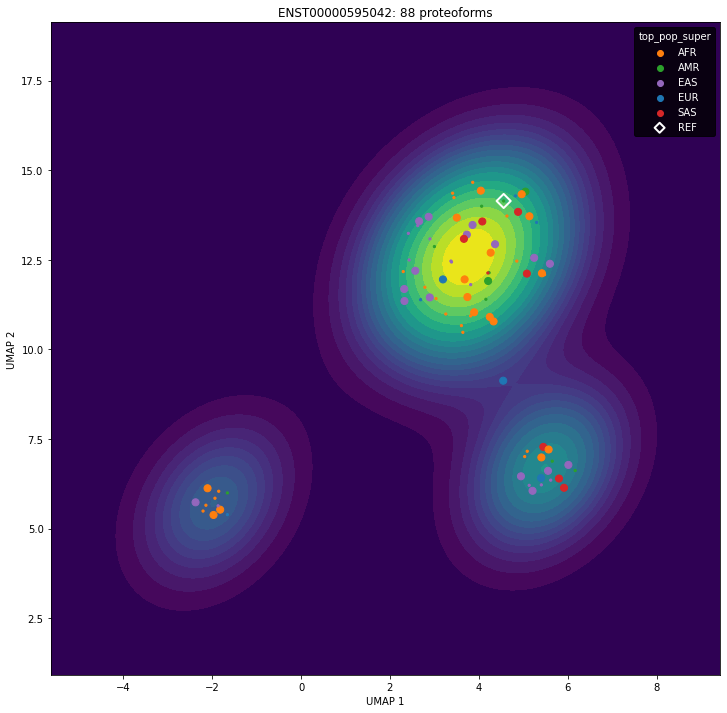

In [196]:
ESM.plot_umap(embedding_df,
        #   facet_col="transcript_id",
          title=f"{tx_id}: {embedding_df.shape[0]} proteoforms",
          highlight_label="REF",
          opacity=1,
          size="freq_all",
          sizes=(5,50),
          color_col="top_pop_super",
#           bw_adjust=0.5, # Decrease bandwidth for higher granularity 
          levels=20, # Increase number of contour levels
          thresh=0.05 # Lower threshold to show more detail
          )